<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
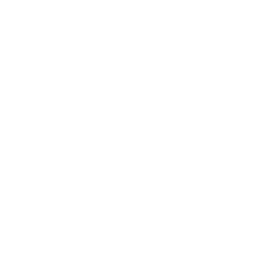
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Surveillance du processus de laminage de l'acier</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; MSP multivarié pour l'épaisseur et la qualité de surface d'un laminoir à bandes à chaud &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé analytique

Un laminoir à bandes à chaud transforme des brames d'acier en bobines
minces. Huit signaux de processus corrélés (épaisseurs, force de
laminage, entrefer des cylindres, courant moteur, température de
sortie) évoluent ensemble lorsque la ligne fonctionne normalement ;
surveiller un seul graphique à la fois passe donc à côté des dérives
conjointes qui comptent. Cet exemple construit une référence
multivariée avec **PROC MVPMODEL**, puis fait défiler 100 bobines de
production dans **PROC MVPMONITOR**, qui note chaque bobine avec une
seule statistique *T*&sup2; de Hotelling et la compare à une limite de
contrôle.

Par rapport à une limite sous contrôle de *T*&sup2; = **17,13**
(&alpha; = 0,05), **4 bobines sur 100** signalent un hors contrôle —
les bobines **91, 92, 94 et 95**, exactement la fenêtre où une rafale
de vibrations des cylindres d'appui a été injectée. Le pic de *T*&sup2;
atteint **21,91** à la bobine 95, soit environ **1,3&times;** la
limite. La montée progressive de l'usure des cylindres sur les bobines
suivantes relève la *T*&sup2; de référence mais reste sous la limite
jusqu'à l'événement de vibrations ; le graphique sépare ainsi
nettement la dérive lente du défaut aigu qui exige une attention
immédiate.

## Sources de données

- **mill_baseline** &mdash; 50 bobines laminées durant une période de
  bon fonctionnement connue de la campagne ; utilisées pour ajuster le
  modèle de référence multivarié (ACP).
- **mill_stream** &mdash; 100 bobines de la ligne en production. Les
  bobines 1&ndash;55 sont sous contrôle ; l'usure des cylindres se
  développe progressivement sur les bobines 56&ndash;100 ; une rafale
  de vibrations des cylindres d'appui frappe les bobines 91&ndash;95.
- **Variables de processus** (6) : `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> L'environnement fonctionne sans licence, les jeux de données sont
> donc plafonnés à 100 observations. Le scénario est dimensionné pour
> cette limite : la perturbation est placée tard dans un flux de 100
> bobines plutôt qu'à la bobine 2 800 sur 5 000.

---

### Étape 1 &mdash; Construire le modèle de référence multivarié

`PROC MVPMODEL` effectue une analyse en composantes principales des
six variables de processus sur la référence sous contrôle et écrit les
saturations, les valeurs propres et le centrage/la mise à l'échelle
dans `mill_model`. Trois composantes sont retenues. Ce modèle définit
ce à quoi ressemble la « normalité » comme une seule région
multivariée plutôt que six plages indépendantes.

In [1]:
DONNÉES mill_baseline;
  APPELER streaminit(66);
  FAIRE coil_id = 1 JUSQU_À 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    SORTIE;
  FIN;
EXÉCUTER;

PROCÉDURE mvpmodel DONNÉES=mill_baseline outmodel=mill_model;
  VAR entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
EXÉCUTER;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Étape 2 &mdash; Faire défiler les bobines de production et les noter

`PROC MVPMONITOR` projette chacune des 100 bobines de production sur
le modèle enregistré et calcule sa statistique *T*&sup2; de Hotelling.
La procédure déduit la limite de contrôle des dimensions du modèle et
du &alpha; = 0,05 par défaut, puis signale toute bobine dont la
*T*&sup2; dépasse cette limite. Les résultats, y compris les colonnes
`_TSQUARED`, `_LIMIT` et `_SIGNAL`, sont écrits dans `mill_scores`,
indexés par `coil_id`.

In [2]:
DONNÉES mill_stream;
  APPELER streaminit(42);
  FAIRE coil_id = 1 JUSQU_À 100;
    /* roll wear ramps 0 -> 1 over coils 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* backup-roll chatter burst on coils 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    SUPPRIMER wear chatter;
    SORTIE;
  FIN;
EXÉCUTER;

PROCÉDURE mvpmonitor DONNÉES=mill_stream MODÈLE=mill_model
                out=mill_scores;
  VAR entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
EXÉCUTER;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Le résumé de la procédure indique la limite de contrôle et le nombre
de signaux. Ci-dessous, l'extrait imprimé autour de la perturbation
montre que les bobines de référence restent bien en dessous de la
limite, tandis que la fenêtre de vibrations pousse quatre bobines
au-dessus.

In [3]:
/* Flag out-of-control coils and capture the alarm T2 for plotting */
DONNÉES mill_scores;
  DÉFINIR mill_scores;
  SI _SIGNAL = 1 ALORS t2_alarm = _TSQUARED;
  SINON t2_alarm = .;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=mill_scores(firstobs=88 obs=96) noobs;
  VAR coil_id _TSQUARED _LIMIT _SIGNAL;
  ÉTIQUETTE coil_id="ID bobine" _TSQUARED="T2 de Hotelling"
        _LIMIT="Limite de contrôle" _SIGNAL="Signal";
  TITRE "Scores T2 dans la fenêtre de vibrations (bobines 88-96)";
EXÉCUTER;


                                Scores T2 dans la fenêtre de vibrations (bobines 88-96)                                 

ID bobine  T2 de Hotelling   Limite de contrôle  Signal
       88         9.983151            17.133408       0
       89         2.915646            17.133408       0
       90          7.80613            17.133408       0
       91        18.813814            17.133408       1
       92        18.249361            17.133408       1
       93        16.638221            17.133408       0
       94        17.981792            17.133408       1
       95        21.912329            17.133408       1
       96         5.118574            17.133408       0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Étape 3 &mdash; Carte de contrôle multivariée

Le graphique superpose la *T*&sup2; par bobine à sa limite de
contrôle. Les bobines hors contrôle sont mises en évidence en rouge ;
le repère vertical en pointillés signale le début de la rafale de
vibrations. La montée lente vers la droite correspond à l'usure des
cylindres qui relève la référence ; les quatre points rouges sont le
défaut aigu de vibrations.

                                Scores T2 dans la fenêtre de vibrations (bobines 88-96)                                 




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


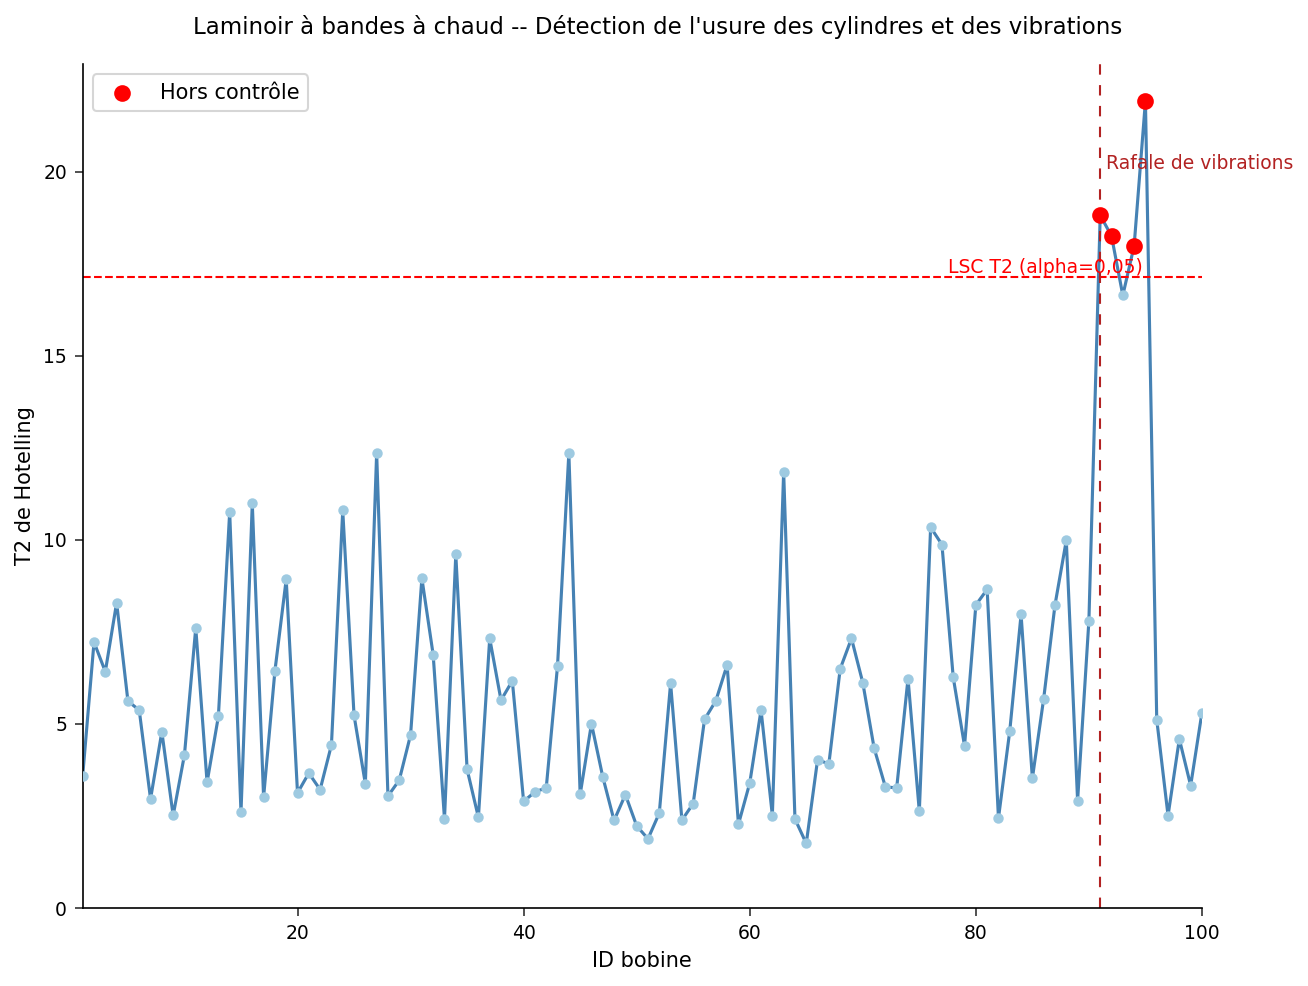

In [4]:
PROCÉDURE SGPLOT DONNÉES=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel="Hors contrôle";
  REFLINE _LIMIT / AXIS=y
          ÉTIQUETTE="LSC T2 (alpha=0,05)"
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ÉTIQUETTE="Rafale de vibrations"
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ÉTIQUETTE="ID bobine" MIN=1 MAX=100;
  YAXIS ÉTIQUETTE="T2 de Hotelling" MIN=0;
  TITRE "Laminoir à bandes à chaud -- Détection de l'usure des cylindres et des vibrations";
EXÉCUTER;


---

### Étape 4 &mdash; Quantifier les bobines hors contrôle

Les bobines hors contrôle sont acheminées vers un jeu de données
distinct pour le service qualité. `PROC MEANS` compare le niveau de
*T*&sup2; des bobines signalées à celui de la population sous
contrôle, et les bobines signalées sont exportées pour l'acheminement
en aval vers la mise au rebut ou la reprise.

In [5]:
DONNÉES mill_ooc;
  DÉFINIR mill_scores;
  SI _SIGNAL = 1;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=mill_scores n mean MAX maxdec=2;
  CLASSE _SIGNAL;
  VAR _TSQUARED;
  ÉTIQUETTE _SIGNAL="Signal" _TSQUARED="T2 de Hotelling";
  TITRE "T2 selon l'état de contrôle (0 = sous contrôle, 1 = signal)";
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=mill_ooc noobs;
  VAR coil_id _TSQUARED _LIMIT;
  ÉTIQUETTE coil_id="ID bobine" _TSQUARED="T2 de Hotelling"
        _LIMIT="Limite de contrôle";
  TITRE "Bobines hors contrôle signalées pour inspection";
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REMPLACER;
EXÉCUTER;


                              T2 selon l'état de contrôle (0 = sous contrôle, 1 = signal)                               

                                                  The MEANS Procedure

                                     Analysis Variable : _TSQUARED T2 de Hotelling

        Signal            N Obs           Mean        Maximum
        -----------------------------------------------------
        0                    96           5.39          16.64
        1                     4          19.24          21.91
        -----------------------------------------------------

                                    Bobines hors contrôle signalées pour inspection                                     

ID bobine  T2 de Hotelling   Limite de contrôle
       91        18.813814            17.133408
       92        18.249361            17.133408
       94        17.981792            17.133408
       95        21.912329            17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Résultats

- **Bobines surveillées** : 100 ; **limite de contrôle** *T*&sup2; =
  **17,13** (&alpha; = 0,05).
- **Bobines hors contrôle** : **4** &mdash; bobines **91, 92, 94, 95**,
  toutes à l'intérieur de la fenêtre de vibrations injectée
  (91&ndash;95). La bobine 93 culmine à *T*&sup2; = 16,64, juste sous
  la limite.
- **Sévérité maximale** : *T*&sup2; = **21,91** à la bobine 95 (environ
  1,3&times; la limite) ; les bobines sous contrôle affichent une
  *T*&sup2; moyenne &asymp; **5,4**.
- **Usure ou défaut** : la montée progressive de l'usure des cylindres
  relève la référence des bobines suivantes mais ne franchit jamais la
  limite à elle seule, si bien que la carte multivariée unique
  distingue la dérive lente (à surveiller) du défaut aigu de
  vibrations (à traiter).
- **Action** : les quatre bobines signalées sont exportées vers
  `steel_mill_ooc_coils.csv` pour inspection et acheminement vers la
  mise au rebut ou la reprise ; la signature des vibrations pointe
  vers le roulement du cylindre d'appui, à inspecter avant la
  prochaine campagne.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>